In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from rdkit import Chem
from rdkit.Chem import Draw

# Aggregation States

A solution is a homogeneous mixture when a solute (drug molecules) is dispersed in a solvent (like water). Aggregration states are how solute particles group or disperse, which impacts solubility, bioavailability, and contributes to aleatoric uncertainty in the AqSolDB dataset.

Aggregation can range from individual molecules (monomers) to clusters (micelles) or even larger particles, depending on factors like concentration, temperature, and molecular properties:


- **Monomers (True Solution):** Individual molecules (<1 nm) at low concentrations.  
  *Example: Dissolved ibuprofen molecules.*

- **Micelles (Colloidal Dispersion):** Clusters (1 nm–1 μm) formed at higher concentrations, where amphiphilic molecules organise with hydrophobic parts inward and hydrophilic parts outward.  
  *Example: Ibuprofen micelles in water.*

- **Suspensions:** Large clumps (>1 μm) that settle out of solution.

In AqSolDB, micelle formation can increase apparent solubility but may also trap drugs, impacting delivery and efficacy.

## Critical Micelle Concentration (CMC)

The **Critical Micelle Concentration (CMC)** is the threshold conc. where amphiphilic molecules, (has both hydrophobic and hydrophilic regions), transition from dispersed monomers to forming micelles.

- **Below CMC:** Molecules exist as monomers, randomly dispersed by Brownian motion.
- **Near/Above CMC:** Hydrophobic interactions drive molecules to cluster, (and minimise hydrophobic exposure to water), thus forming micelles.

## Hydrophobic Effect

This is the main cause of micelle formation: where hydrophobic regions of amphiphilic molecules avoid water by clustering to minimise the surface area exposed to water. This reduces the system's free energy, which can be approximated by:

$$
\Delta G = RT \ln(\text{CMC})
$$

where $R $ is the gas constant (8.314 J/mol·K), $T $ is temperature (K), and CMC is in mol/L.

## Lennard-Jones Potential

This captures intermolecular interactions, including van der Waals attraction and short-range repulsion:

$$
V(r) = 4\varepsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right]
$$

- $r $: Distance between molecule parts  
- $\varepsilon $: Strength of attraction (energy well depth)  
- $\sigma $: Distance where potential is zero

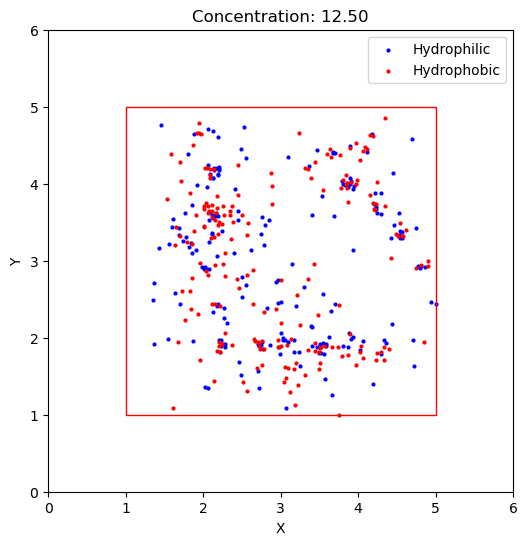

In [ ]:
np.random.seed(42)
n_particles = 200

# Large box -> low conc., small box -> high conc.
initial_box_size = 6.0
final_box_size = 4.0

# Amphiphile parameters
bead_dist = 0.25 # Distance between hydrophilic and hydrophobic in dumbbell
hydrophilic_color = 'blue'
hydrophobic_color = 'red'

# Interaction strengths
eps_hydrophobic = 0.5 # Attraction between hydrophobic beads
eps_hydrophilic = 0.05 # Repulsion between hydrophilic beads
eps_cross = 0.05 # Repulsion between hydrophilic and hydrophobic beads
sigma = 0.15

dt = 0.05
damping = 0.92
wall_damp = 0.8
brownian_strength = 0.2
torque_strength = 0.1

# Each particle: [x, y, theta]
positions = np.random.rand(n_particles, 2) * initial_box_size
angles = np.random.rand(n_particles) * 2 * np.pi
velocities = np.zeros((n_particles, 2))
angular_velocities = np.zeros(n_particles)

def get_bead_positions(positions, angles):
    hydrophilic = positions + bead_dist * np.stack([np.cos(angles), np.sin(angles)], axis=1)
    hydrophobic = positions - bead_dist * np.stack([np.cos(angles), np.sin(angles)], axis=1)
    return hydrophilic, hydrophobic

def lj_force(r, epsilon, sigma):
    r = np.clip(r, 1e-6, None)
    term = sigma / r
    return np.clip(24 * epsilon * (2 * term**13 - term**7) / r, -5, 5)

fig, ax = plt.subplots(figsize=(6, 6))
hydrophilic_scat = ax.scatter([], [], s=4, color=hydrophilic_color, label='Hydrophilic')
hydrophobic_scat = ax.scatter([], [], s=4, color=hydrophobic_color, label='Hydrophobic')
ax.set_xlim(0, initial_box_size)
ax.set_ylim(0, initial_box_size)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Micelle Formation with Amphiphilic Particles')
ax.legend(loc="upper right")
box_patch = ax.add_patch(plt.Rectangle((0,0), initial_box_size, initial_box_size, fill=False, edgecolor='red'))

def update(frame):
    global positions, velocities, angles, angular_velocities

    # Hold at final size for a bit
    if frame > 200:
        frame = 200

    # Shrink box, increase conc.
    box_size = initial_box_size - (initial_box_size - final_box_size) * (frame / 200)
    concentration = n_particles / (box_size ** 2)
    lower_bound = (initial_box_size - box_size) / 2
    upper_bound = lower_bound + box_size

    hydrophilic, hydrophobic = get_bead_positions(positions, angles)
    forces = np.zeros((n_particles, 2))
    torques = np.zeros(n_particles)

    # Pairwise attractions
    for i in range(n_particles):
        for j in range(i + 1, n_particles):
            # Hydrophobic-hydrophobic (attractive)
            diff_hh = hydrophobic[i] - hydrophobic[j]
            dist_hh = np.linalg.norm(diff_hh)
            f_hh = lj_force(dist_hh, eps_hydrophobic, sigma) * diff_hh / (dist_hh + 1e-8)
            forces[i] += f_hh
            forces[j] -= f_hh

            # Hydrophilic-hydrophilic (repulsive)
            diff_ee = hydrophilic[i] - hydrophilic[j]
            dist_ee = np.linalg.norm(diff_ee)
            f_ee = lj_force(dist_ee, -eps_hydrophilic, sigma) * diff_ee / (dist_ee + 1e-8)
            forces[i] += f_ee
            forces[j] -= f_ee

            # Hydrophilic-hydrophobic (repulsive)
            diff_eh = hydrophilic[i] - hydrophobic[j]
            dist_eh = np.linalg.norm(diff_eh)
            f_eh = lj_force(dist_eh, -eps_cross, sigma) * diff_eh / (dist_eh + 1e-8)
            forces[i] += f_eh
            forces[j] -= f_eh

            diff_he = hydrophobic[i] - hydrophilic[j]
            dist_he = np.linalg.norm(diff_he)
            f_he = lj_force(dist_he, -eps_cross, sigma) * diff_he / (dist_he + 1e-8)
            forces[i] += f_he
            forces[j] -= f_he

            # Torques: align hydrophilic away from hydrophobic neighbors (crude)
            # If hydrophobic beads are close, rotate so hydrophilic points outward
            if dist_hh < 2 * bead_dist:
                vec = hydrophobic[j] - hydrophobic[i]
                angle_to_j = np.arctan2(vec[1], vec[0])
                dtheta = np.arctan2(np.sin(angle_to_j - angles[i]), np.cos(angle_to_j - angles[i]))
                torques[i] -= torque_strength * dtheta
                torques[j] += torque_strength * dtheta

    # Brownian motion
    forces += np.random.normal(0, brownian_strength, size=forces.shape)
    torques += np.random.normal(0, brownian_strength * 0.5, size=torques.shape)

    velocities += dt * forces
    velocities *= damping
    positions += dt * velocities

    angular_velocities += dt * torques
    angular_velocities *= damping
    angles += dt * angular_velocities

    # Reflect and bounce off walls
    hydrophilic, hydrophobic = get_bead_positions(positions, angles)
    for i in range(n_particles):
        for d in [0, 1]:
            
            # Hydrophilic bead
            bead_pos = hydrophilic[i, d]
            if bead_pos < lower_bound:
                shift = lower_bound - bead_pos
                positions[i, d] += shift
                velocities[i, d] = -velocities[i, d] * wall_damp
            elif bead_pos > upper_bound:
                shift = upper_bound - bead_pos
                positions[i, d] += shift
                velocities[i, d] = -velocities[i, d] * wall_damp
            
            # Hydrophobic bead
            bead_pos = hydrophobic[i, d]
            if bead_pos < lower_bound:
                shift = lower_bound - bead_pos
                positions[i, d] += shift
                velocities[i, d] = -velocities[i, d] * wall_damp
            elif bead_pos > upper_bound:
                shift = upper_bound - bead_pos
                positions[i, d] += shift
                velocities[i, d] = -velocities[i, d] * wall_damp

    hydrophilic, hydrophobic = get_bead_positions(positions, angles)
    hydrophilic_scat.set_offsets(hydrophilic)
    hydrophobic_scat.set_offsets(hydrophobic)
    box_patch.set_xy((lower_bound, lower_bound))
    box_patch.set_width(box_size)
    box_patch.set_height(box_size)
    ax.set_title(f'Concentration: {concentration:.2f}')
    return hydrophilic_scat, hydrophobic_scat

ani = FuncAnimation(fig, update, frames=300, interval=50, blit=True)
ani.save('aggregation.gif', writer='pillow', fps=20)